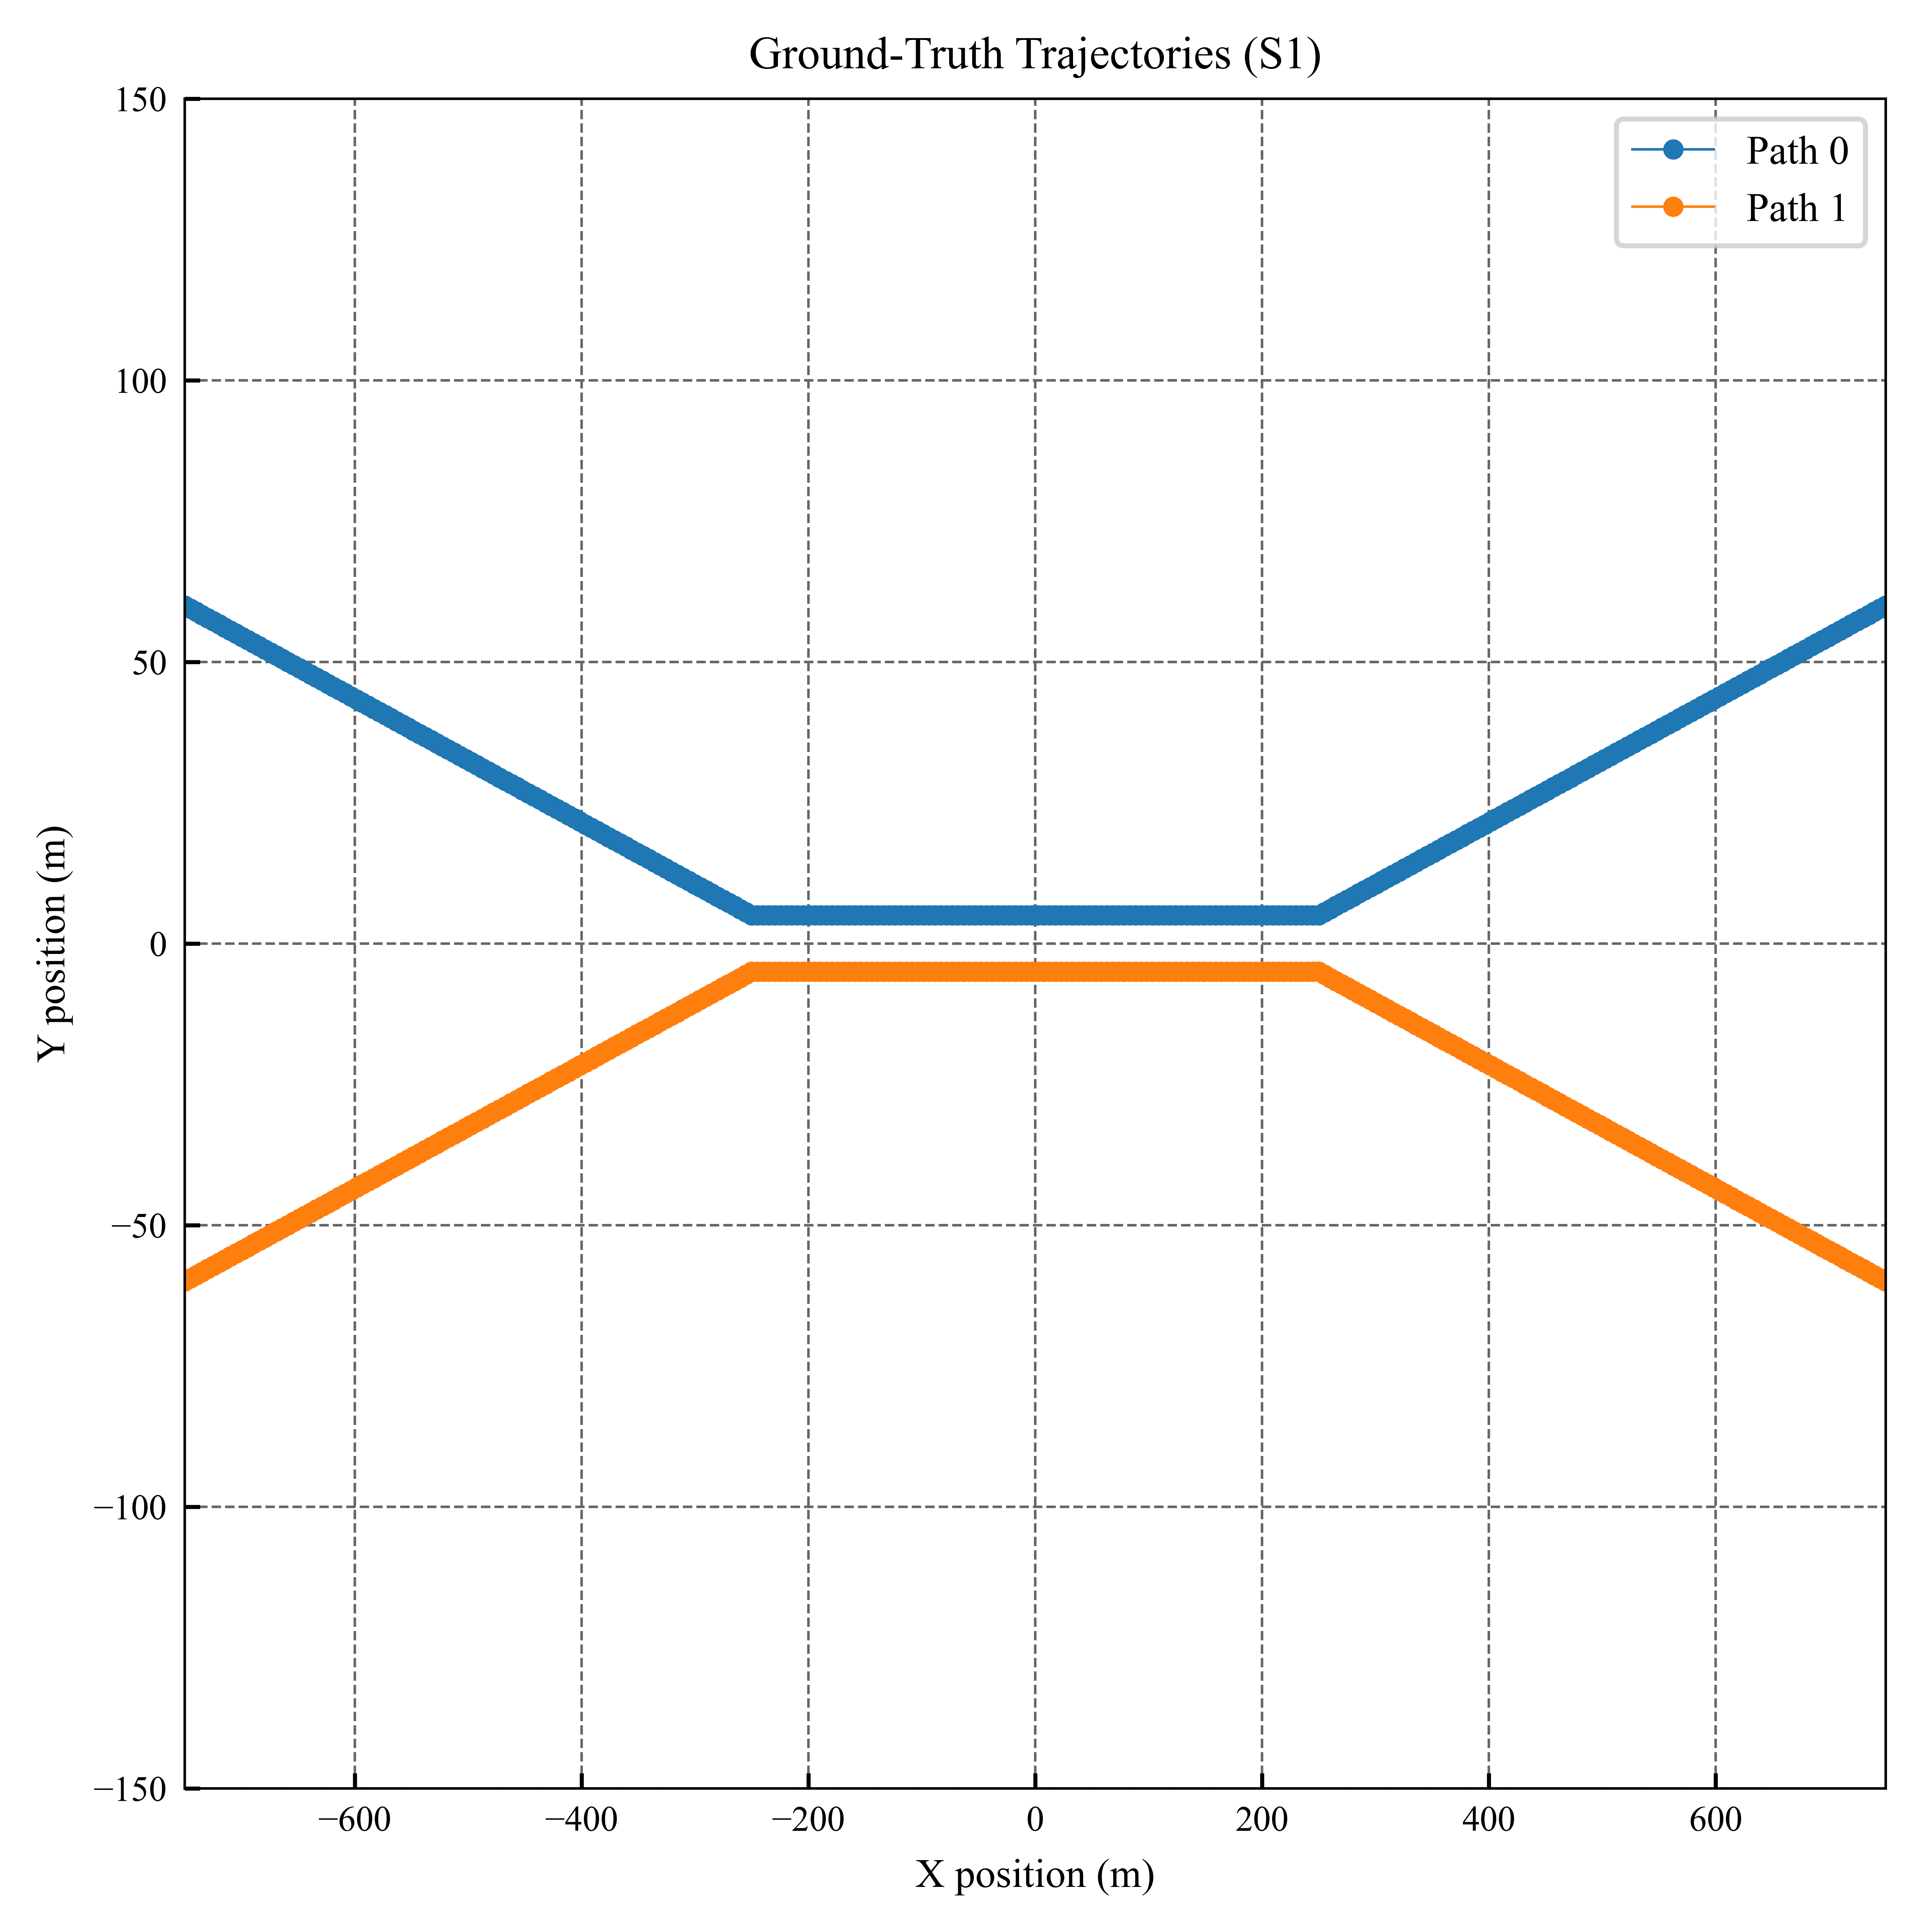

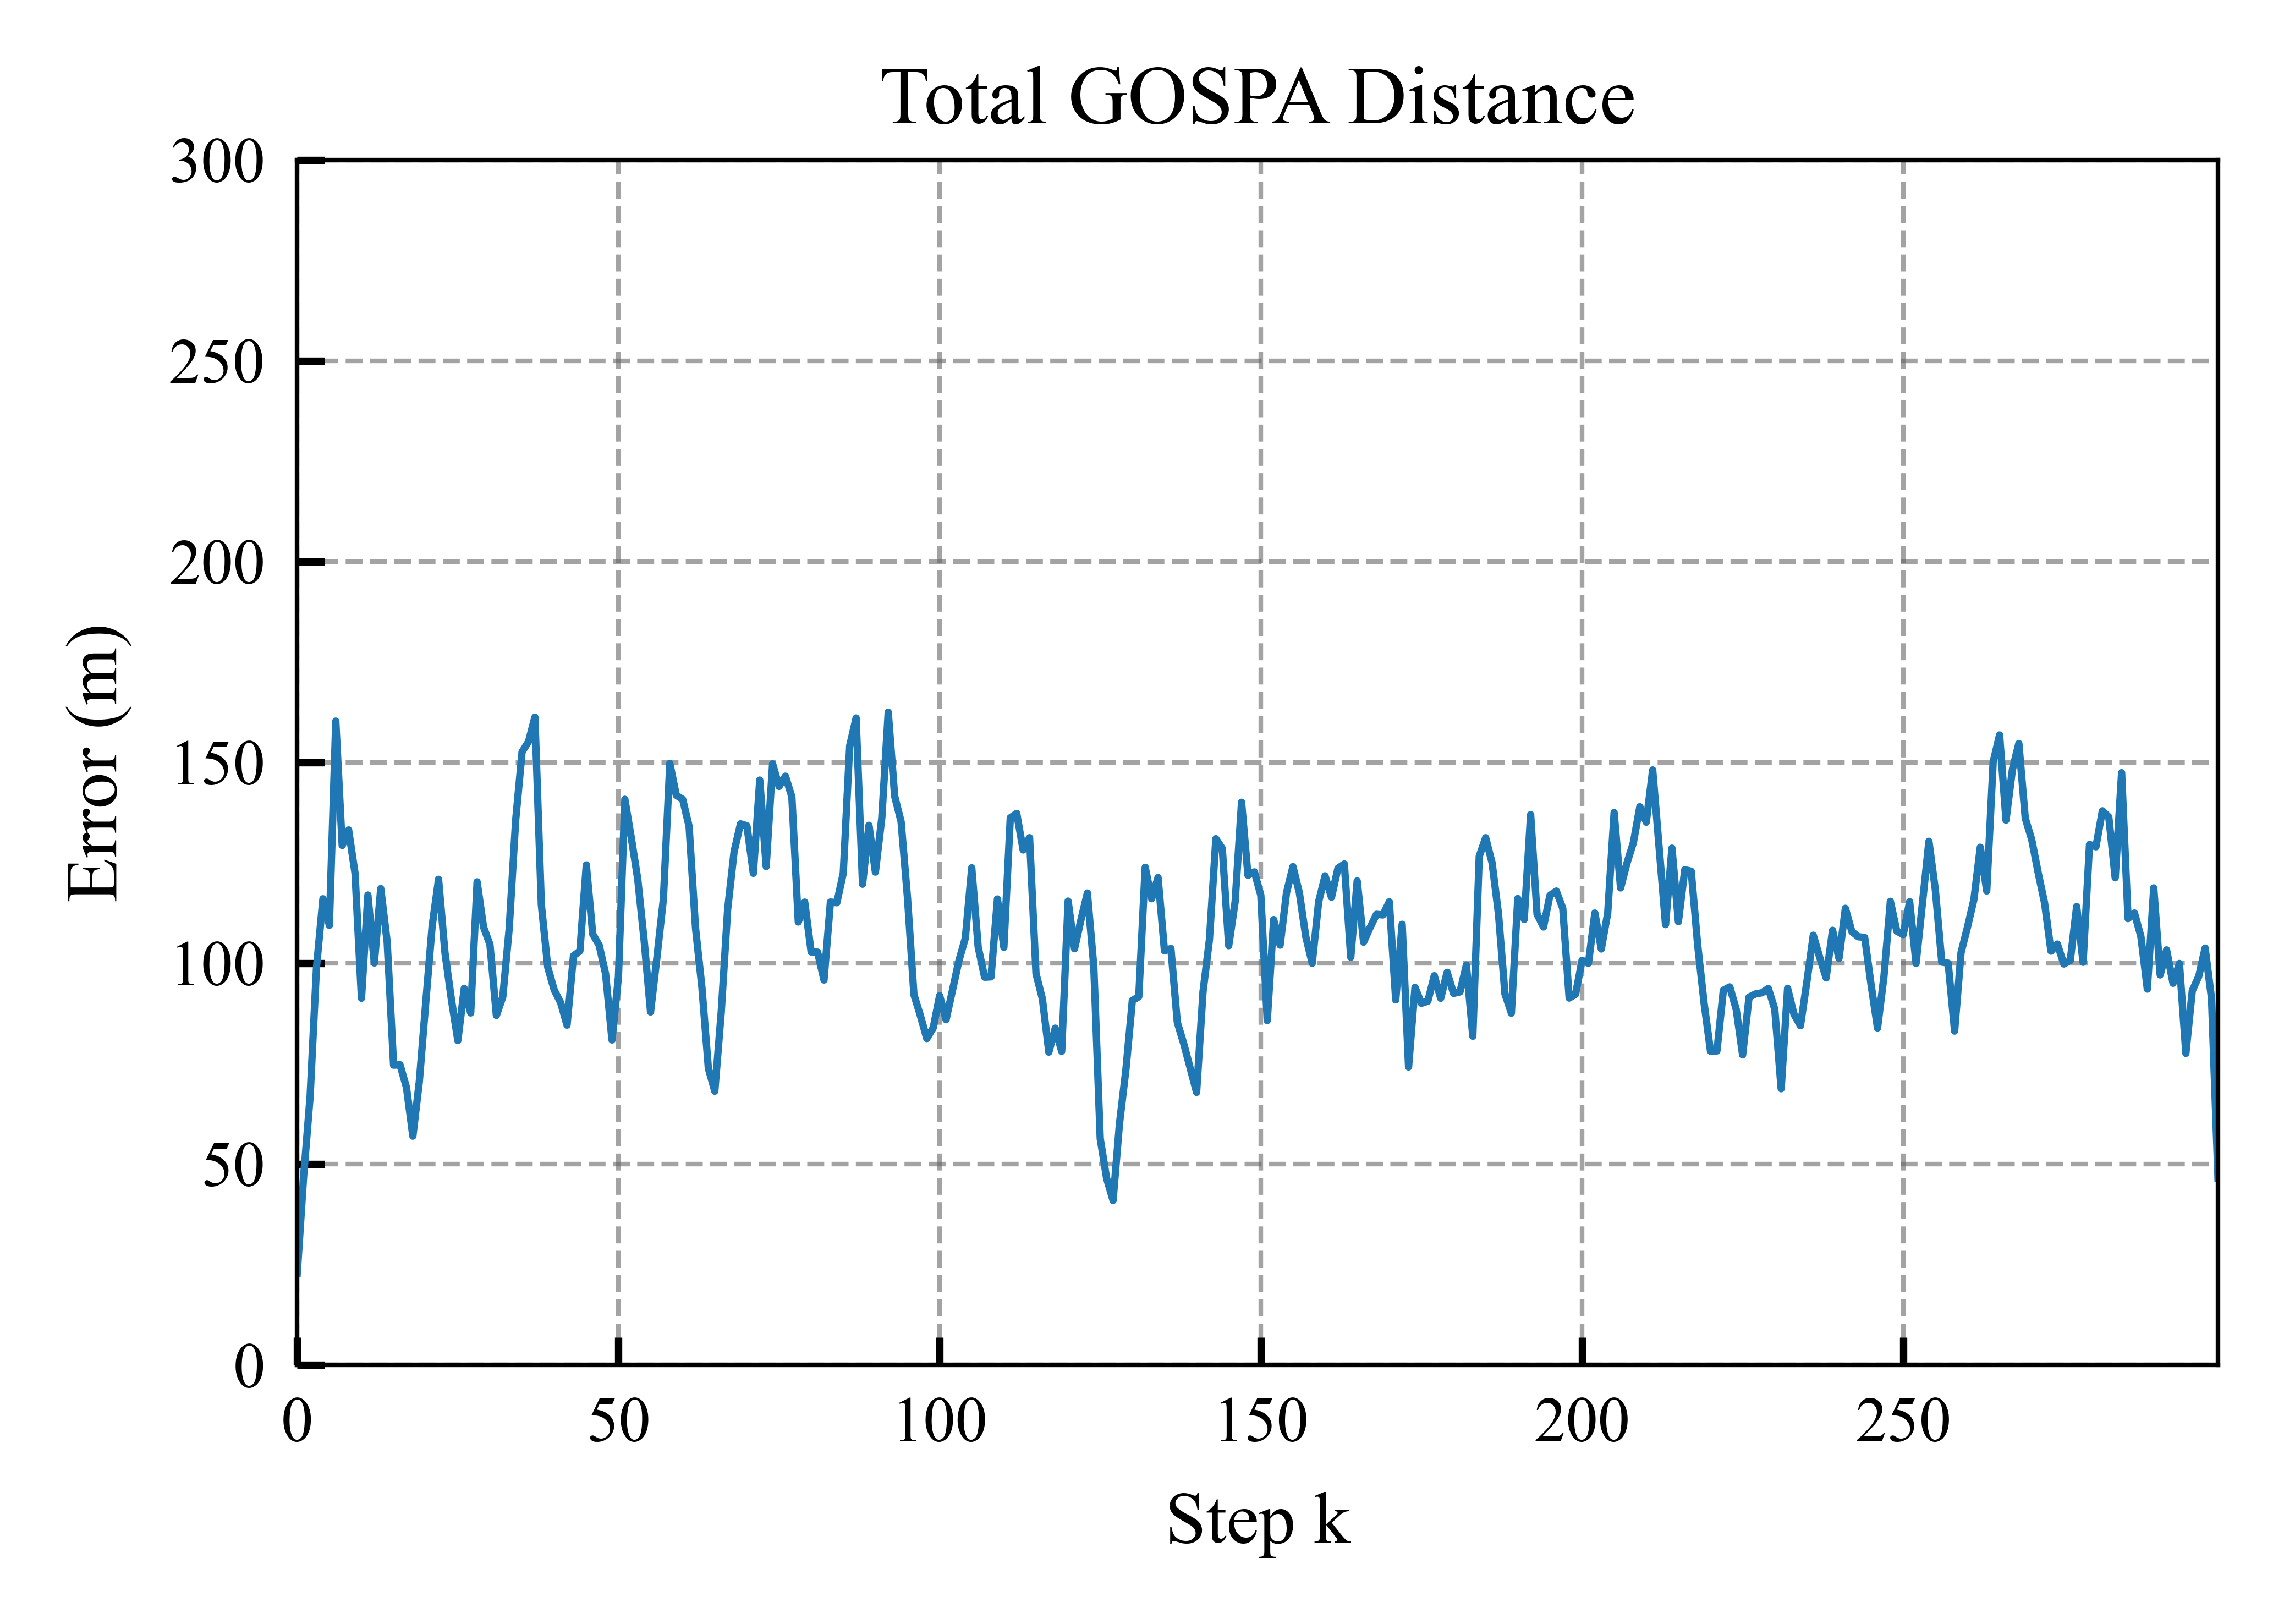

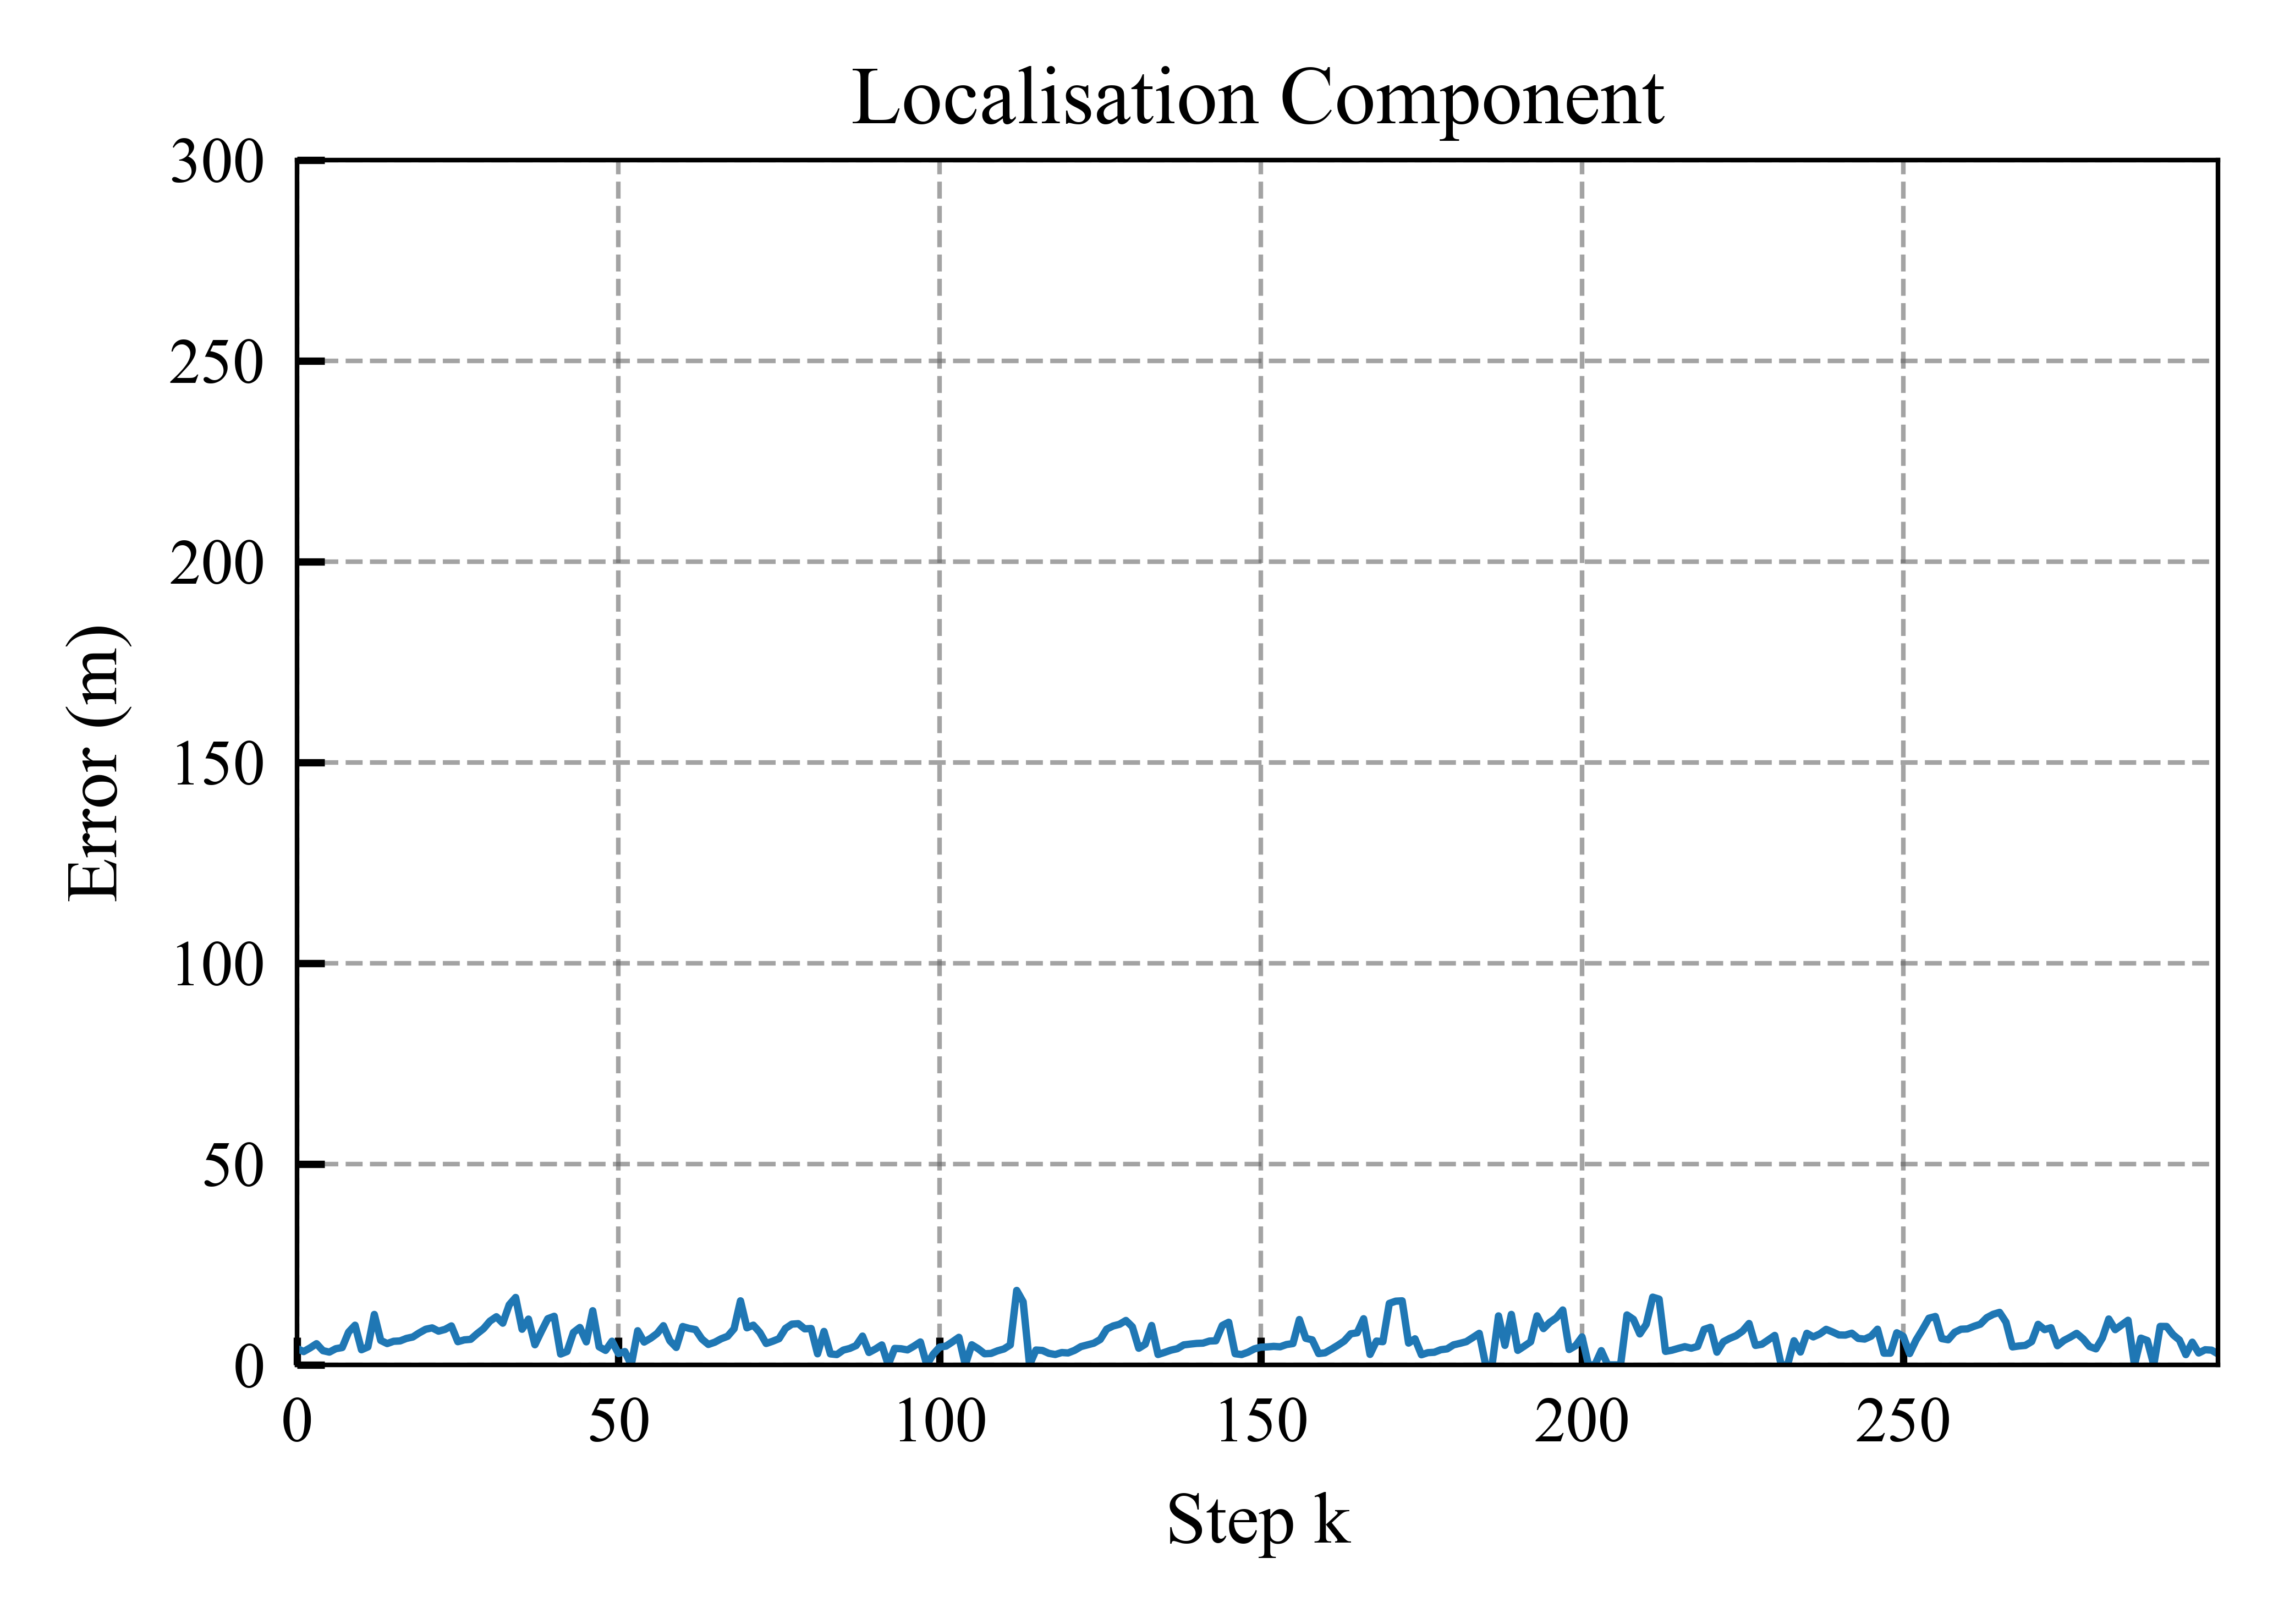

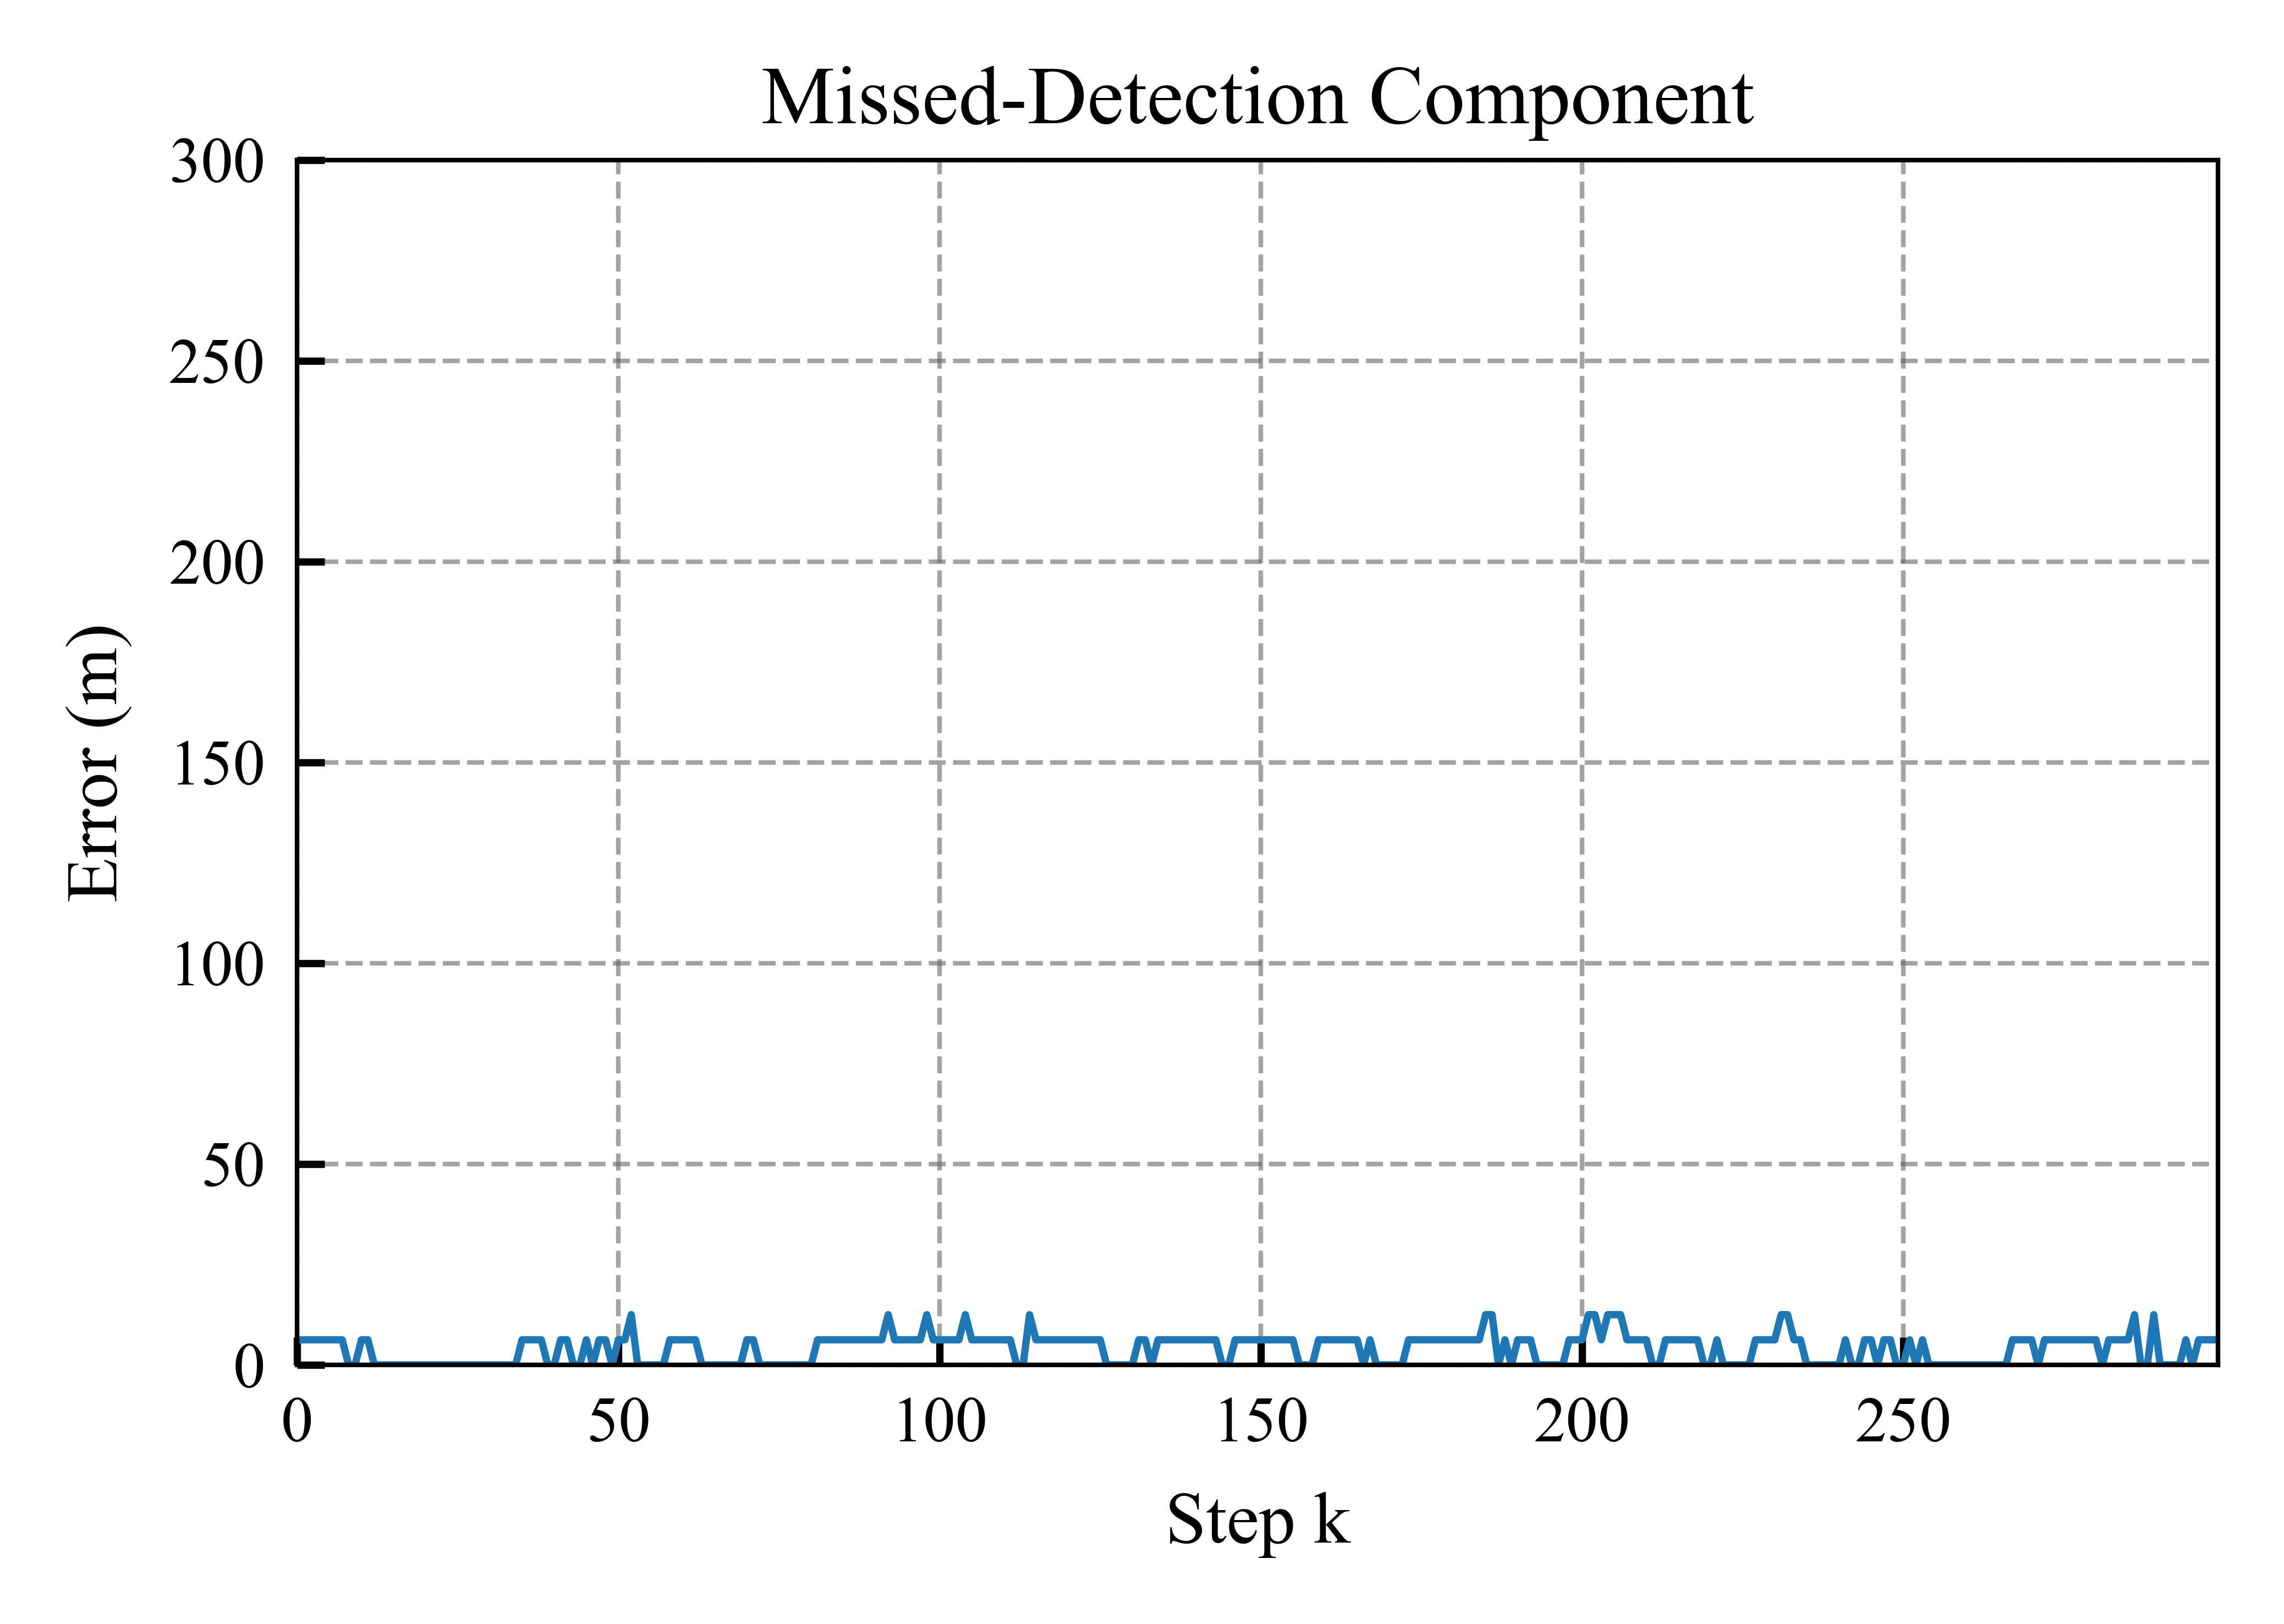

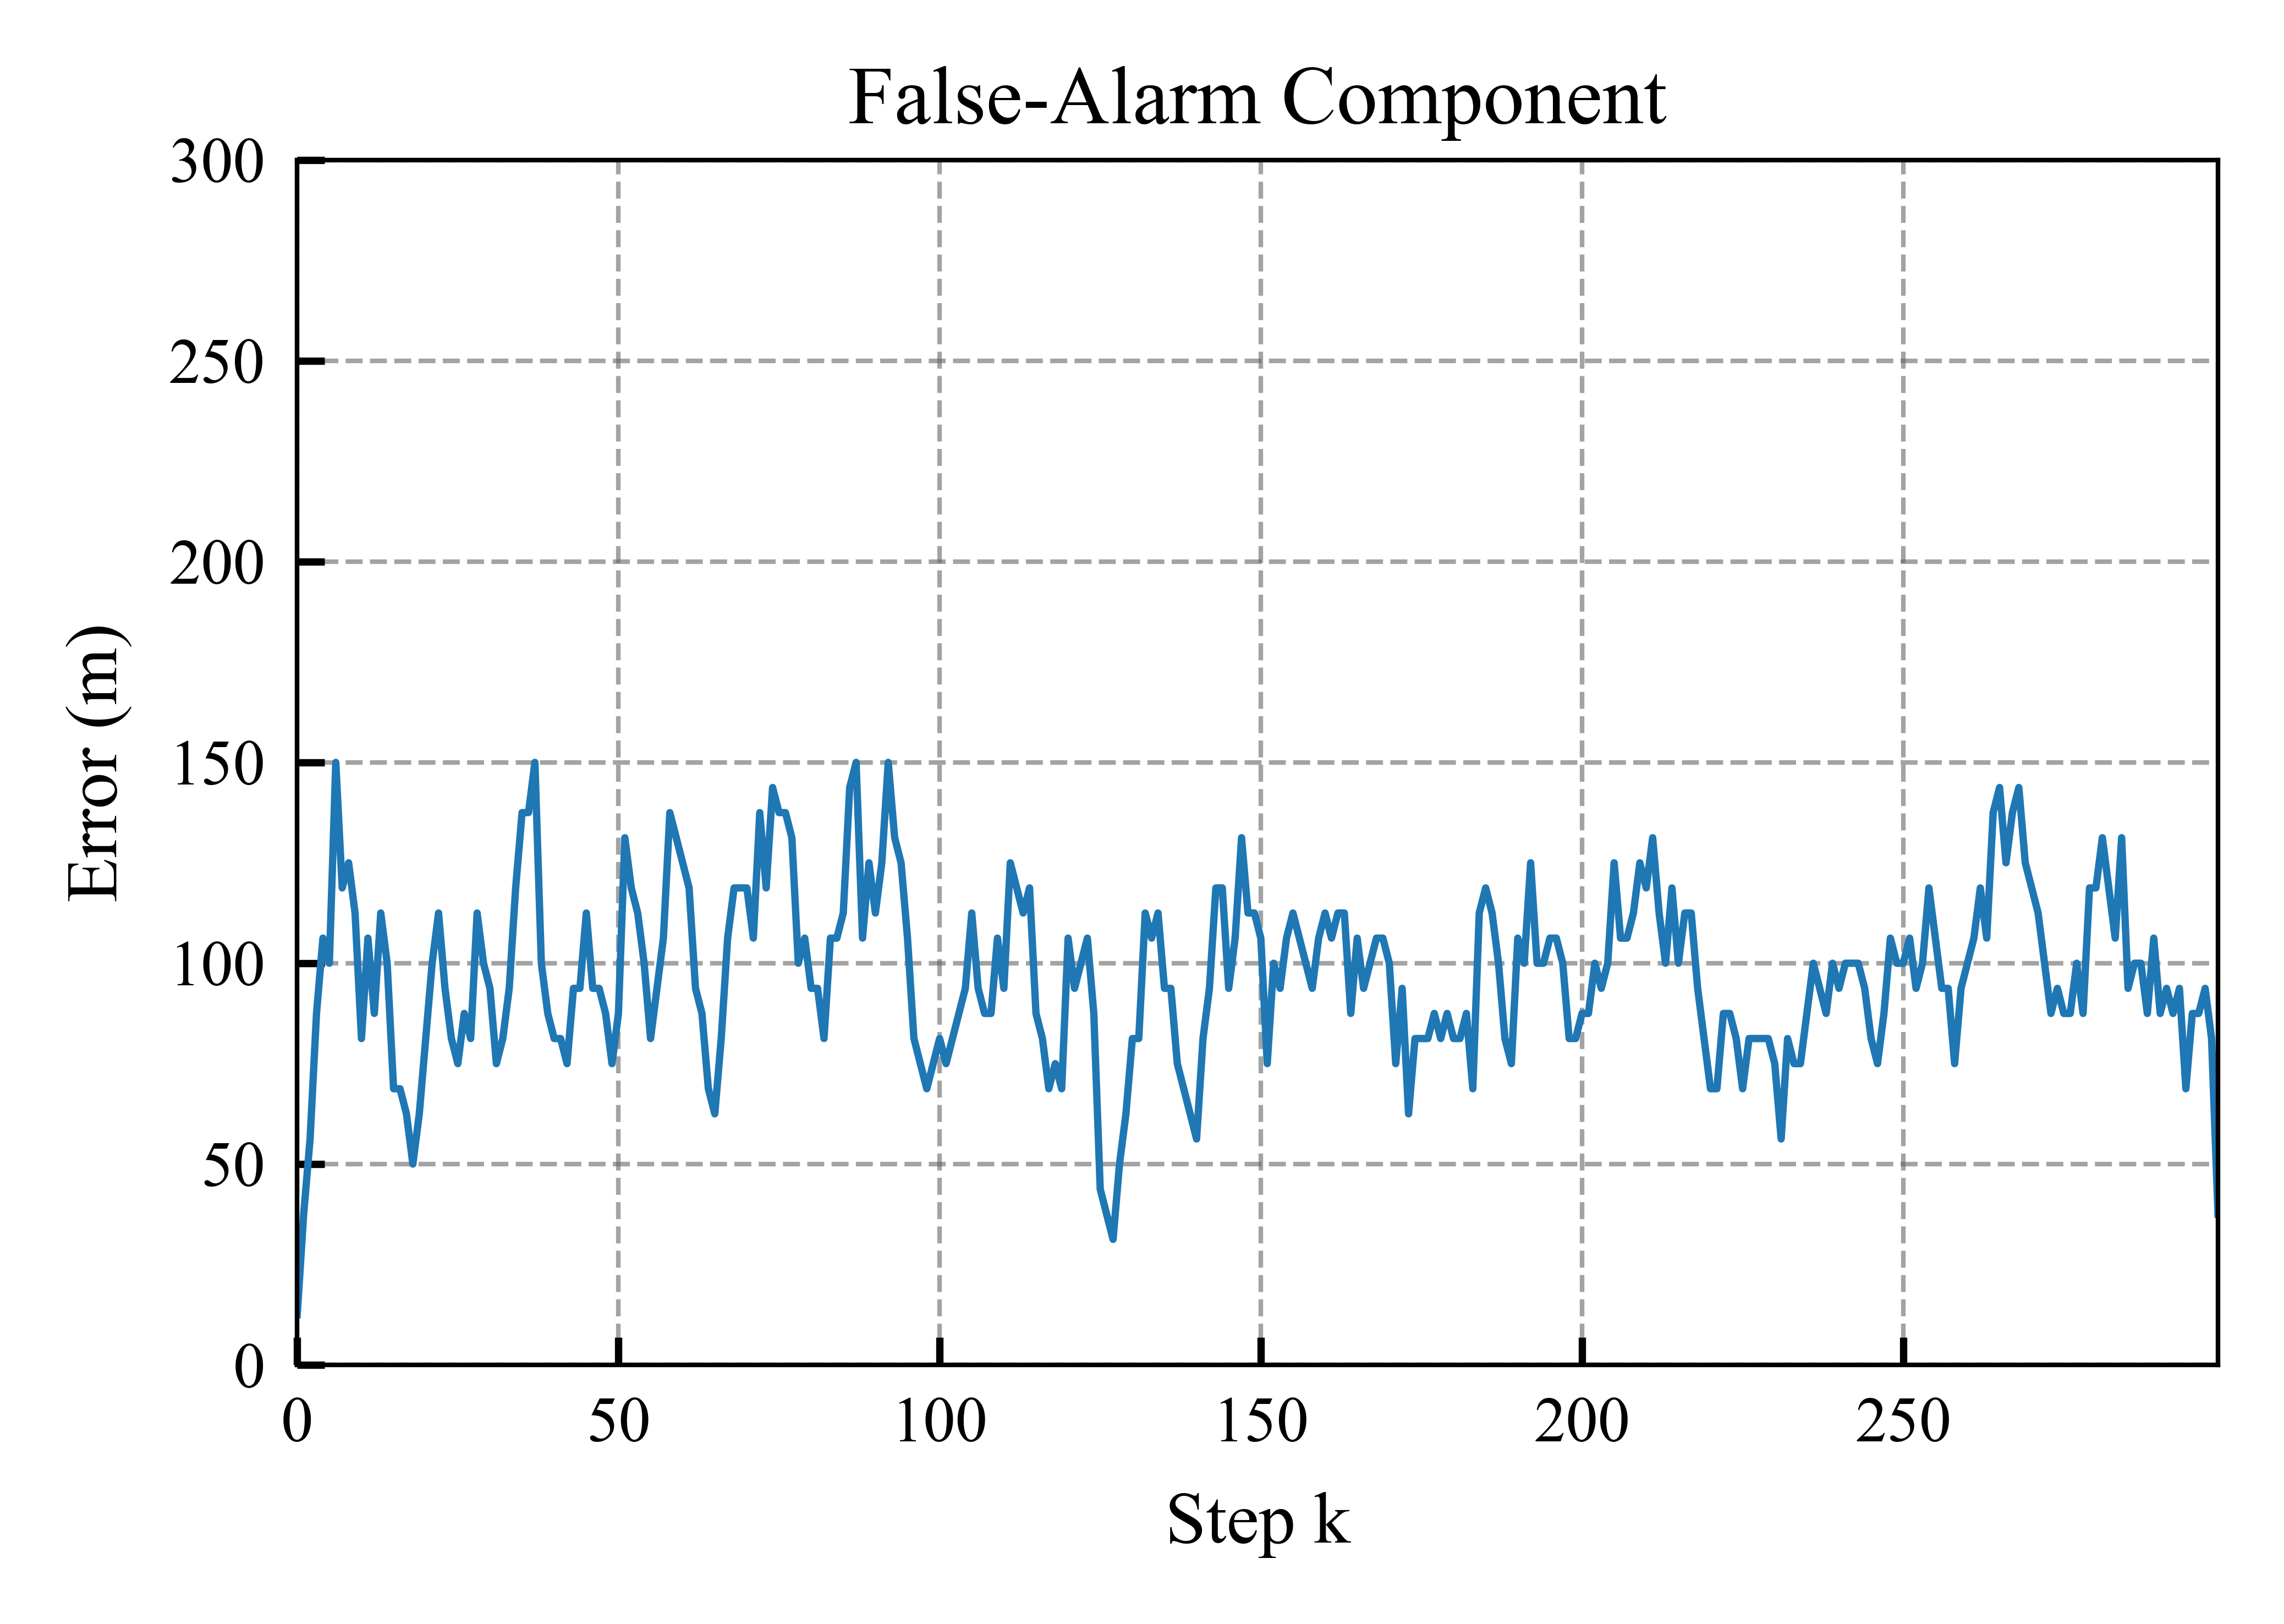

In [33]:
# Independent Generator for GOSPA Metrics and Sub-Components
# -----------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Stone Soup imports
from stonesoup.types.array        import StateVector, CovarianceMatrix
from stonesoup.types.state        import GaussianState
from stonesoup.types.groundtruth  import GroundTruthPath
from stonesoup.platform.base      import FixedPlatform
from stonesoup.simulator.platform import PlatformDetectionSimulator
from stonesoup.sensor.radar.radar import RadarBearingRange
from stonesoup.models.clutter     import ClutterModel
from stonesoup.models.measurement.linear import LinearGaussian
from stonesoup.types.numeric import Probability
from stonesoup.types.groundtruth import GroundTruthState


from stonesoup.tracker.simple        import MultiTargetMixtureTracker
from stonesoup.initiator.simple      import MultiMeasurementInitiator
from stonesoup.hypothesiser.distance import DistanceHypothesiser
from stonesoup.deleter.time          import UpdateTimeDeleter
from stonesoup.dataassociator.probability import JPDAwithLBP as JPDA 
from stonesoup.hypothesiser.probability   import PDAHypothesiser
from stonesoup.models.transition.linear   import CombinedLinearGaussianTransitionModel, ConstantVelocity
from stonesoup.predictor.kalman            import ExtendedKalmanPredictor
from stonesoup.updater.kalman              import ExtendedKalmanUpdater
from stonesoup.metricgenerator.ospametric import GOSPAMetric
from stonesoup.metricgenerator.manager    import MultiManager
from stonesoup.measures import Mahalanobis
from stonesoup.measures import Euclidean
from stonesoup.simulator.simple import SimpleDetectionSimulator
from stonesoup.dataassociator.neighbour import GNNWith2DAssignment
from scipy.signal import savgol_filter

# 0) basic class
class SimpleGT:
    def __init__(self, paths):
        # assume all paths have same length+timestamps
        self.paths = paths

    def __iter__(self):
        return self.groundtruth_paths_gen()

    def groundtruth_paths_gen(self):
        length = len(self.paths[0].states)
        for step in range(length):
            t = self.paths[0].states[step].timestamp
            # yield the partial paths up to this scan
            yield t, {
                GroundTruthPath(
                    path.states[: step + 1], id=path.id
                )
                for path in self.paths
            }

# 1) Your S1 ground-truth generator
def build_s1_paths(start_time, dt, num_steps):
    # 1) the two “full” waypoint sequences
    waypoint_lists = [
        [(-750,  60), (-250,   5), ( 250,   5), ( 750,  60)],
        [(-750, -60), (-250,   -5), ( 250,   -5), ( 750, -60)]
    ]

    paths = []
    # how many segments per target? 3
    num_segs = len(waypoint_lists[0]) - 1
    # split steps as evenly as possible
    base_steps = num_steps // num_segs
    extra      = num_steps %  num_segs

    for tid, wpts in enumerate(waypoint_lists):
        states = []
        step_idx = 0
        # loop over each segment
        for seg in range(num_segs):
            p0 = wpts[seg]
            p1 = wpts[seg+1]
            # distribute the “extra” one‐offs into the first few segments
            seg_steps = base_steps + (1 if seg < extra else 0)

            for k in range(seg_steps):
                frac = k/(seg_steps-1) if seg_steps>1 else 0.0
                x = p0[0] + frac*(p1[0]-p0[0])
                y = p0[1] + frac*(p1[1]-p0[1])
                t = start_time + step_idx*dt
                step_idx += 1

                # metadata “index” is needed for the SimpleDetectionSimulator
                states.append(GroundTruthState(
                    state_vector=StateVector([x,0.0,y,0.0]).reshape(4,1),
                    timestamp=t,
                    metadata={"index": tid}
                ))
        paths.append(GroundTruthPath(states, id=tid))

    return paths

# 2) Monte-Carlo + GOSPA loop

# a) initial time values and parameters
num_runs  = 1
num_steps = 300
all_dist  = np.empty((num_runs, num_steps))
all_loc   = np.empty_like(all_dist)
all_miss  = np.empty_like(all_dist)
all_false = np.empty_like(all_dist)
start_time=datetime.now()

# b) Platform for Sensor
platform = FixedPlatform(
        GaussianState(StateVector([0,0,0,0]).reshape(4,1),
                    CovarianceMatrix(np.eye(4)), timestamp=start_time),
        position_mapping=(0,2)
    )

# c) Transition Model and EKF Predictor
process_noise = 0.1
transition_model = CombinedLinearGaussianTransitionModel([
        ConstantVelocity(process_noise),
        ConstantVelocity(process_noise)
    ])
predictor_EKF = ExtendedKalmanPredictor(transition_model)

# d) Measurement model
sigma   = 10.0      
meas_model = LinearGaussian(
    ndim_state=4,            # Using statevector - [x, vx, y, vy]
    mapping=(0, 2),          
    noise_covar=CovarianceMatrix(
        np.diag([sigma**2, sigma**2])
    )
)

# e) Sensor Model and Clutter
mu_c = 10
roi  = ((-750, 750), (-750, 750))
clutter = ClutterModel(
    clutter_rate=mu_c,
    distribution=np.random.default_rng().uniform,
    dist_params=roi
)
roi_area        = 1500 * 1500
clutter_density = mu_c / roi_area
p_d             = 0.5

sensor = RadarBearingRange(
        ndim_state=4,
        position_mapping=(0, 2),     
        noise_covar=meas_model.noise_covar,
        clutter_model=clutter
    )

# f) Adding sensor to Platform and EKF Updater
sensor._measurement_model   = meas_model
sensor.detection_probability = p_d
platform.add_sensor(sensor)
updater_EKF   = ExtendedKalmanUpdater(sensor)

# g) PDA Hypothesiser
pda_hyp_ekf = PDAHypothesiser(
        predictor               = predictor_EKF,
        updater                 = updater_EKF,
        clutter_spatial_density = clutter_density,
        prob_detect             = p_d,
        prob_gate = Probability(0.95)
)

# h) JPDA Object
da_jpda_ekf = JPDA(hypothesiser=pda_hyp_ekf)

# i) Initiators
init_hyp_ekf  = DistanceHypothesiser(predictor_EKF, updater_EKF,
                                     measure=Mahalanobis(),
                                     missed_distance=13.82)
init_assoc_ekf = GNNWith2DAssignment(init_hyp_ekf)

prior = GaussianState(
    StateVector([[-750], [10], [150], [0]]),
    0.1*np.array([[1/3, 0, 1/2, 0],[0, 1/3, 0, 1/2],[1/2, 0, 1, 0],[0, 1/2, 0, 1]])
)

deleter = UpdateTimeDeleter(timedelta(seconds=1), delete_last_pred=False)

initiator_jpda_ekf = MultiMeasurementInitiator(
        prior_state      = prior,
        measurement_model= meas_model,
        deleter          = deleter,
        data_associator  = init_assoc_ekf,
        updater          = updater_EKF,
        min_points       = 2
    )


# j) Monte Carlo Loop
for run in range(num_runs):
    # a) Ground Truth
    start_time = datetime.now()
    dt         = timedelta(seconds=1)
    gt_paths   = build_s1_paths(start_time, dt, num_steps=num_steps)

    plt.figure(figsize=(6,6))
    for path in gt_paths:
        xs = [state.state_vector[0, 0] for state in path.states]
        ys = [state.state_vector[2, 0] for state in path.states]
        plt.plot(xs, ys, marker='.', label=f'Path {path.id}')

    plt.xlabel('X position (m)')
    plt.ylabel('Y position (m)')
    plt.title('Ground-Truth Trajectories (S1)')
    plt.legend()
    plt.grid(True)
    plt.xlim(-750, 750)
    plt.ylim(-150, 150)
    plt.show()


    # b) Detector
    gt_reader = SimpleGT(gt_paths)
    detector = SimpleDetectionSimulator(
        groundtruth=gt_reader,
        measurement_model=meas_model,
        meas_range=np.array([[-750, 750],[-750, 750]]),
        detection_probability=p_d,
        clutter_rate=mu_c
    )
    detector_iter = iter(detector)

    # c) Tracker
    tracker_EKF_JPDAF = MultiTargetMixtureTracker(
        initiator       = initiator_jpda_ekf,
        deleter         = deleter,
        detector        = detector,
        data_associator = da_jpda_ekf,
        updater         = updater_EKF
    )

    tracker_EKF_JPDAF_iter = iter(tracker_EKF_JPDAF)

    metric_sim  = SimpleDetectionSimulator(
        groundtruth=gt_reader,
        measurement_model=meas_model,
        meas_range=np.array([[-750, 750],[-750, 750]]),
        detection_probability=p_d,
        clutter_rate=mu_c
    )
    metric_iter = iter(metric_sim)

    # d) GOSPA Metric 
    gospa_gen      = GOSPAMetric(
        p=1, c=50,
        switching_penalty=0.0,
        measure=Euclidean(),
        tracks_key='EKF_tracks',
        truths_key='truths',
        generator_name='GOSPA_EKF_vs_Truth'
    )

    # e) Metric Manager
    metric_manager = MultiManager([gospa_gen])
    for k in range(num_steps):
        t_det, raw_dets = next(metric_iter)
        if isinstance(raw_dets, dict):
            detections = raw_dets[platform]
        else:
            detections = list(raw_dets)

        t_trk, tracks   = next(tracker_EKF_JPDAF_iter)
        truths = [path.states[k] for path in gt_paths]


        metric_manager.add_data({
            'truths': truths,
            'EKF_tracks': tracks,
            'detections': detections
        }, overwrite=False)

    # f) Final Processing
    metrics = metric_manager.generate_metrics()
    gm = metrics['GOSPA_EKF_vs_Truth']['GOSPA Metrics'].value
    full_dist  = np.array([mv.value['distance']     for mv in gm])
    full_loc   = np.array([mv.value['localisation'] for mv in gm])
    full_miss  = np.array([mv.value['missed']       for mv in gm])
    full_false = np.array([mv.value['false']        for mv in gm])

    dist_row  = full_dist [:num_steps]
    loc_row   = full_loc  [:num_steps]
    miss_row  = full_miss [:num_steps]
    false_row = full_false[:num_steps]

    all_dist [run, :] = dist_row
    all_loc  [run, :] = loc_row
    all_miss [run, :] = miss_row
    all_false[run, :] = false_row

# End Loop

# 3) Stack and average
dist_arr   = np.vstack(all_dist)    # shape (1000,300)
loc_arr    = np.vstack(all_loc)
miss_arr   = np.vstack(all_miss)
false_arr  = np.vstack(all_false)

mean_dist  = dist_arr.mean(axis=0) / 4.0
mean_loc   = loc_arr.mean(axis=0) / 4.0
mean_miss  = miss_arr.mean(axis=0) / 4.0
mean_false = false_arr.mean(axis=0) / 4.0

# Grab the timestamps once (same for every run)
times = [mv.timestamp for mv in gm]

# 4) Plot each component in its own IEEE-style panel
import matplotlib.pyplot as plt


plt.rcParams.update({
    'font.family':    'serif',
    'font.serif':     ['Times New Roman','Times'],
    'font.size':      8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize':7,
    'ytick.labelsize': 7,
    'axes.linewidth':0.5,
    'lines.linewidth':0.5,
    'xtick.direction':'in',
    'ytick.direction':'in',
    'xtick.major.size':3,
    'ytick.major.size':3,
    'grid.linestyle':'--',
    'grid.linewidth':0.5,
    'grid.color':'#666666',
    'figure.dpi':1200,
})

components = {
    'Total GOSPA Distance':       mean_dist,
    'Localisation Component':     mean_loc,
    'Missed-Detection Component': mean_miss,
    'False-Alarm Component':      mean_false,
}

for title, vals in components.items():
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    smooth = savgol_filter(vals, window_length=51, polyorder=3, mode='interp')
    x = np.arange(len(smooth))
    ax.plot(x, vals, linewidth=0.8)          


    ax.set_title(title, pad=4)
    ax.set_xlabel('Step k')
    ax.set_ylabel('Error (m)')
    ax.grid(True, alpha=0.6)

    # enforce identical axes limits
    ax.set_xlim(0, num_steps-1)                
    ax.set_ylim(0, 300)                      

    plt.tight_layout()
    plt.show()